In [ ]:
# This will delete all variables from the current session
%reset -f

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from typing import Literal
from datetime import datetime, timedelta

In [ ]:
ara_data_folder = "../../data/newsapi/downloads/ara/"
eng_data_folder = "../../data/newsapi/downloads/eng/"

plot_path = "../../plots/"

In [ ]:
# English
eng = pd.read_csv(eng_data_folder + "Mashreq_2024-06-23_2024-07-24_daily_article_eng_clean.csv")
eng["date"] = pd.to_datetime(eng["date"])

/tmp/ipykernel_23320/2811966821.py:2: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  eng = pd.read_csv(eng_data_folder + "Mashreq_2024-06-23_2024-07-24_daily_article_eng_clean.csv")


In [ ]:
# Arabic
ara = pd.read_csv(eng_data_folder + "Mashreq_2024-06-23_2024-07-24_daily_article_ara_clean.csv")
ara["date"] = pd.to_datetime(ara["date"])

In [ ]:
# Exclude the dates from the language dataframes to make sure that we only include entire weeks
from_date = "2024-06-24"
to_date = "2024-07-21"

In [ ]:
# English
eng = eng.loc[(eng["date"] >= from_date) & (eng["date"] <= to_date),]

In [ ]:
# Arabic
ara = ara.loc[(ara["date"] >= from_date) & (ara["date"] <= to_date),]

In [ ]:
# Function to count keyword occurrences in an article
def count_keywords(article, paywall_keywords):
    return sum(article.lower().count(keyword) for keyword in paywall_keywords)

# 1. English articles

In [ ]:
# Defining a list of words likely to appear in paywalls
paywall_keywords_eng = [
    "subscribe",
    "subscription",
    "sign up",
    "subscribe now",
    "register",
    "register now",
    "become a subscriber",
    "exclusive content",
    "member",
    "membership",
    "paywall",
    "pay",
    "payment",
    "purchase",
    "paid content",
    "buy now",
    "access to",
    "read more",
    "continue reading",
    "read the full article",
    "log in to read more",
    "unlock",
    "access"
    "get access",
    "full access",
    "free trial",
    "start your free trial",
    "trial period",
    "login",
    "log in",
    "already a subscriber?",
    "only available to subscribers",
    "upgrade",
    "upgrade your plan",
    "sign in",
    "sign in to continue",
    "premium",
    "join now",
    "create an account",
    "limited access",
    "exclusive access",
    "premium content",
    "exclusive articles",
    "limited content",
    "subscription required",
    "password"
]

In [ ]:
# Apply the function to the DataFrame
eng['paywall_keyword_count'] = eng['body'].apply(count_keywords, args=(paywall_keywords_eng,))
eng["article_length"] = eng['body'].apply(lambda x: len(x.split(" ")))
eng["paywall_probability"] = eng["paywall_keyword_count"] / eng["article_length"]

In [ ]:
paywall_200 = eng.sort_values("paywall_probability", ascending = False).head(200)[["paywall_probability", "url", "source", "body"]]

In [ ]:
paywall_200.to_csv(eng_data_folder + "paywall_200.csv", index = False)

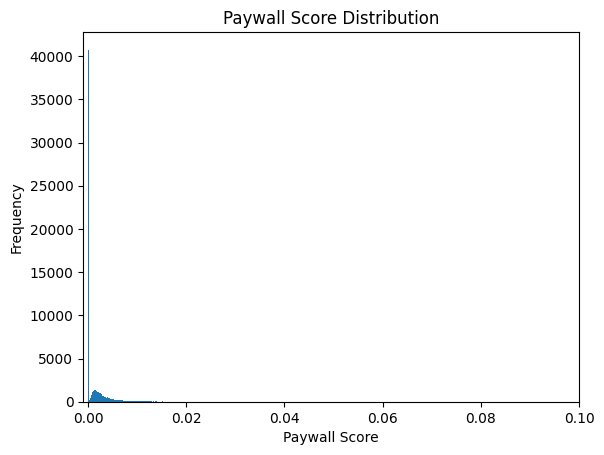

In [ ]:
plt.hist(eng['paywall_probability'], bins=1000)
plt.title('Paywall Score Distribution')
plt.xlabel('Paywall Score')
plt.ylabel('Frequency')
plt.xlim(-0.001, 0.1)
plt.show()

In [ ]:
sum(eng["paywall_keyword_count"] == 0)

40740

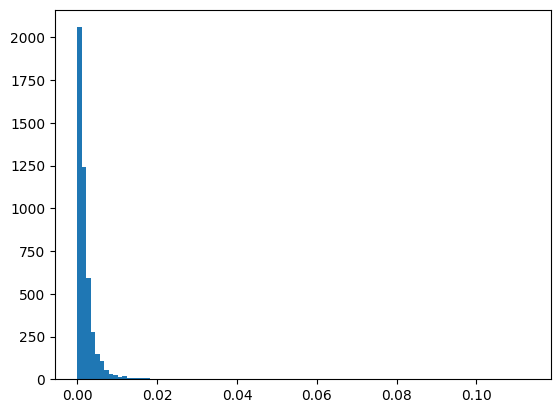

In [ ]:
plt.hist(eng.groupby("source")["paywall_probability"].mean(), bins=100)
plt.show()

# 2. Arabic articles

In [ ]:
paywall_keywords_ara = [
    "اشترك", "اشترك الآن", "لمتابعة", "للاطلاع", "مقال مدفوع",
    "محتوى خاص", "تسجيل الدخول", "إصدار بريميوم", "إشتراك",
    "إلغاء الاشتراك", "اشتركت", "تفعيل الاشتراك", "استمر في القراءة",
    "عرض كامل", "محتوى حصري", "حسابك", "ترقية", "التسجيل",
    "تسجيل الدخول لمتابعة القراءة", "اشترِ الآن", "المقال الكامل",
    "الدفع", "اشتر الآن", "الوصول الكامل", "القراءة الكاملة",
    "مقال كامل", "إشترك لتستفيد", "إشتراكك", "محتوى مدفوع",
    "عرض المزيد", "المزيد من التفاصيل", "إدارة الحساب",
    "قم بتسجيل الدخول", "تسجيل الدخول لقراءة المزيد", "ادفع الآن",
    "مقالة مدفوعة", "اشترك لمتابعة", "الاشتراك", "العضوية",
    "تابع القراءة", "حصري لأعضاء", "الترقية", "الوصول إلى المحتوى"
]

In [ ]:
paywall_keywords_ara2 = [
    "اشترك", "اشتراك", "سجل", "اشترك الآن", "تسجيل", "سجل الآن",
    "كن مشتركًا", "محتوى حصري", "عضو", "عضوية", "حاجز دفع",
    "ادفع", "دفع", "شراء", "محتوى مدفوع", "اشترِ الآن", "الوصول إلى",
    "اقرأ المزيد", "استمر في القراءة", "اقرأ المقال كاملاً",
    "سجل الدخول لقراءة المزيد", "افتح", "وصول", "احصل على وصول",
    "وصول كامل", "تجربة مجانية", "ابدأ تجربتك المجانية",
    "فترة تجريبية", "تسجيل الدخول", "تسجيل الدخول",
    "هل أنت مشترك بالفعل؟", "متاح فقط للمشتركين", "ترقية",
    "قم بترقية خطتك", "تسجيل الدخول", "تسجيل الدخول للمتابعة",
    "بريميوم", "انضم الآن", "أنشئ حسابًا", "وصول محدود",
    "وصول حصري", "محتوى بريميوم", "مقالات حصرية", "محتوى محدود",
    "يتطلب الاشتراك", "كلمة المرور"
]


In [ ]:
# Apply the function to the DataFrame
ara['paywall_keyword_count'] = ara['body'].apply(count_keywords, args=(paywall_keywords_ara2,))
ara["article_length"] = ara['body'].apply(lambda x: len(x.split(" ")))
ara["paywall_probability"] = ara["paywall_keyword_count"] / ara["article_length"]

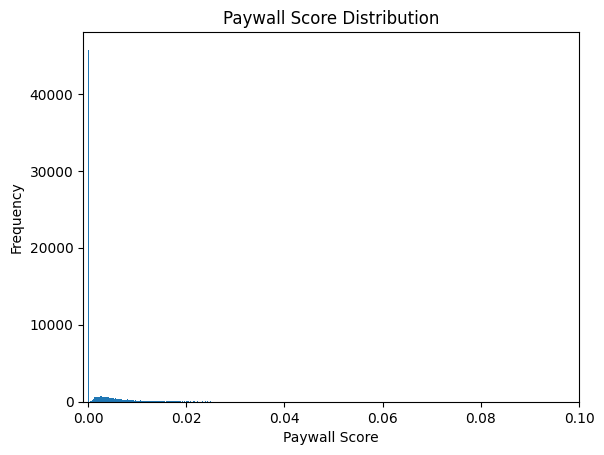

In [ ]:
plt.hist(ara['paywall_probability'], bins=1000)
plt.title('Paywall Score Distribution')
plt.xlabel('Paywall Score')
plt.ylabel('Frequency')
plt.xlim(-0.001, 0.1)
plt.show()